In [1]:
# ==========================================
# Imports
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from anova_module import ModelAnalysis , batch_shapley_values

In [2]:
# ==========================================
# Processing
# ==========================================

# 1. Download and load the UCI Mushroom dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"
# The UCI file has no headers, so we read it without them
df = pd.read_csv(url, header=None)

# 2. Split X and y
# The first column (column 0) is the class: 'e' (edible) or 'p' (poisonous)
y = df.iloc[:, 0]        # target
X = df.iloc[:, 1:]       # features

# 3. Encode y as binary (0/1)
# Convention: 1 = poisonous, 0 = edible
y_encoded = (y == "p").astype(int)

# 4. Encode X features as integers
# Simple method using pandas: category codes (0, 1, 2, ...)
X_cat = X.apply(lambda col: col.astype("category").cat.codes)

X_encoded = X_cat.to_numpy()
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42
)

# 5. Train the XGBoost model
print("Training XGBoost model...")
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# 6. Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy on test set: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training XGBoost model...

Accuracy on test set: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [3]:
%%time
# ==========================================
# Functional ANOVA
# ==========================================

def f(x): # function of interest : Pr(Tree classify x as poisonous)
    return(model.predict_proba(x)[:, 1])

d = X_encoded.shape[1]
A = ModelAnalysis(X_encoded , f , 1.07 , 1e-3 , 1e-10) # tests have shown that 1.07% is the exact percentage to stop at last singleton set
S , Matrix = A.functional_anova() # sets and f_A(X_A)
main_effects = Matrix
Order_1 = np.sum(np.abs(Matrix.T * A.get_P()), axis=1)
print(A.get_R2() , A.get_L2_Error() , A.get_L2_Error_rel())

Constructing Basis Matrix: 100%|██████████| 86/86 [00:00<00:00, 978.27it/s]


Computations complete. Results ready.
0.9999920823152834 1.967318597826237e-06 4.091452625338771e-06
CPU times: user 1.05 s, sys: 131 ms, total: 1.18 s
Wall time: 255 ms


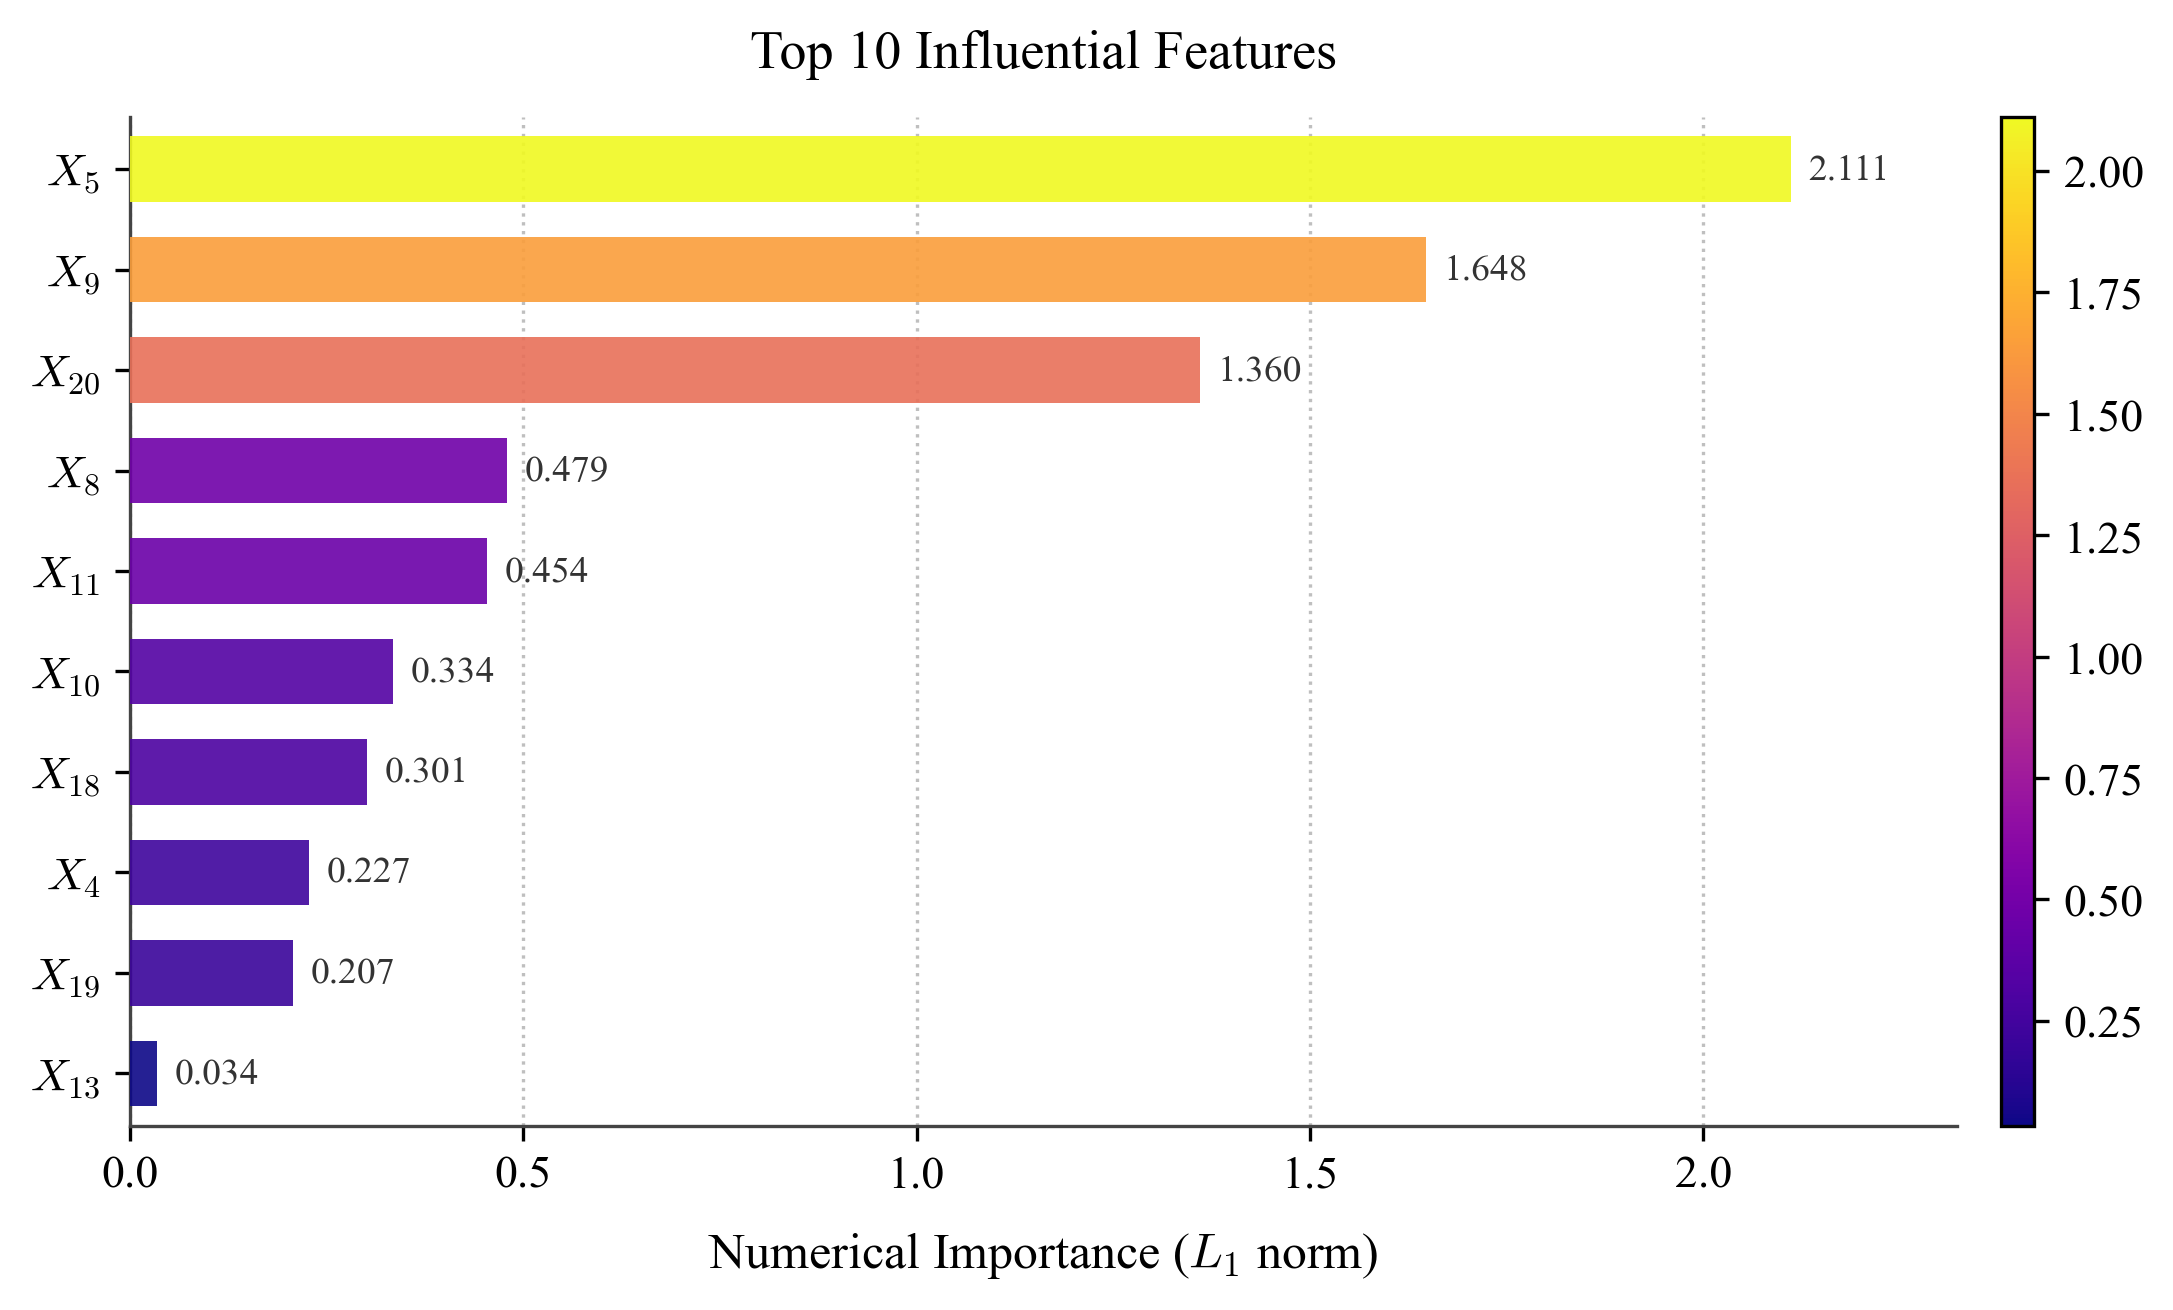

In [ ]:
# ==========================================
# Plot
# ==========================================

scores = np.asarray(Order_1[1:])
feature_names = np.array([f"$X_{{{s[0]}}}$" for s in S[1:]])

# Sorting and selection
top_n = 10
sorted_idx = np.argsort(np.abs(scores))
top_idx = sorted_idx[-top_n:]

features_sorted = feature_names[top_idx]
scores_sorted = scores[top_idx]

abs_scores = np.abs(scores_sorted)

norm = mcolors.Normalize(vmin=np.min(abs_scores), vmax=np.max(abs_scores))

cmap = plt.get_cmap('plasma') 

# C. Generate colors for each bar
bar_colors = cmap(norm(abs_scores))

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 11,
    "axes.labelsize": 12,
    "figure.dpi": 300
})

fig, ax = plt.subplots(figsize=(8, 4.5))
y_pos = np.arange(len(features_sorted))

rects = ax.barh(
    y_pos, 
    scores_sorted, 
    height=0.65,
    color=bar_colors,  
    alpha=0.9,         
    edgecolor='none',
    zorder=3
)

ax.set_yticks(y_pos)
ax.set_yticklabels(features_sorted)

ax.set_xlabel(r"Numerical Importance ($L_1$ norm)", labelpad=8)
ax.set_title("Top 10 Influential Features", pad=12, fontsize=13)

# Cleanup (Spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#444444')
ax.spines['bottom'].set_color('#444444')
ax.grid(axis='x', linestyle=':', alpha=0.5, color='gray', zorder=0)

# Value annotations
x_span = ax.get_xlim()[1] - ax.get_xlim()[0]
offset = x_span * 0.01

for rect, color_val in zip(rects, bar_colors):
    w = rect.get_width()
    label_x_pos = w + offset if w >= 0 else w - offset
    ha_alignment = 'left' if w >= 0 else 'right'
    
    ax.text(
        label_x_pos,
        rect.get_y() + rect.get_height() / 2,
        f"{w:.3f}",
        ha=ha_alignment,
        va='center',
        fontsize=9,
        color="#333333", 
        fontfamily="serif"
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, aspect=30, pad=0.02)
cbar.set_label('', rotation=270, labelpad=15)

plt.margins(y=0.02, x=0.1)
plt.tight_layout()

# Save
# plt.savefig("l1_importance_mushrooms.pdf", format='pdf', bbox_inches='tight')
plt.show()